In [28]:
import torch 
from torchvision.datasets import CIFAR10
from torchvision import transforms

# Dataset 

In [61]:
train_data =  CIFAR10(root="/tmp/cifar10",train=True,download=True)
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /tmp/cifar10
    Split: Train

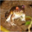

In [30]:
x,y = train_data[0]
x # PIL (Python Image library | the modern one is Pillow )

In [31]:
print(x)
print(y)

<PIL.Image.Image image mode=RGB size=32x32 at 0x17EEB30E0>
6


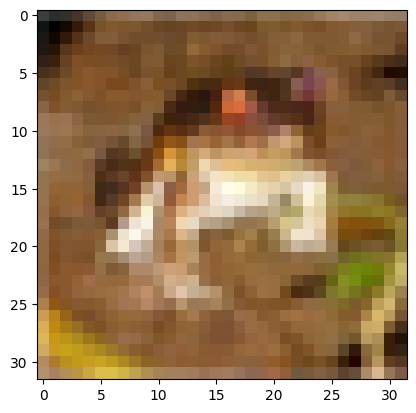

In [32]:
import matplotlib.pyplot as plt 

plt.imshow(x)

# Transformations 

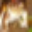

In [33]:
transforms.RandomResizedCrop(size=32,scale=(0.08,1))(x)

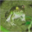

In [34]:
transforms.ColorJitter(brightness=0.4,contrast=0.4,saturation=0.2,hue=0.2)(x)

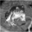

In [35]:
transforms.Grayscale(num_output_channels=3)(x)

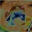

In [36]:
transforms.functional.solarize(x,threshold=128)

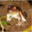

In [37]:
transforms.functional.hflip(x)

In [38]:
transforms.ToTensor()(x)    # Torch image aka. [C,H,W]

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

The argument for `transforms.Normalize` must be Torch Image 

In [39]:
transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))(transforms.ToTensor()(x))

tensor([[[-1.2854e+00, -1.5955e+00, -1.4598e+00,  ...,  6.3375e-01,
           5.1744e-01,  4.3990e-01],
         [-2.1189e+00, -2.4291e+00, -2.0801e+00,  ..., -4.4721e-02,
          -1.2226e-01, -6.4106e-02],
         [-1.9444e+00, -2.1189e+00, -1.4792e+00,  ..., -1.4165e-01,
          -1.0288e-01, -3.1611e-01],
         ...,
         [ 1.6030e+00,  1.4673e+00,  1.4091e+00,  ...,  6.7252e-01,
          -1.3435e+00, -1.4017e+00],
         [ 1.0602e+00,  9.2452e-01,  1.1765e+00,  ...,  1.1378e+00,
          -5.4873e-01, -8.2012e-01],
         [ 1.0021e+00,  8.2760e-01,  1.0408e+00,  ...,  1.7581e+00,
           4.9806e-01, -4.4721e-02]],

        [[-1.1989e+00, -1.5136e+00, -1.4742e+00,  ...,  1.7777e-01,
           4.0101e-02,  2.0434e-02],
         [-2.0249e+00, -2.4183e+00, -2.2609e+00,  ..., -6.8757e-01,
          -7.8591e-01, -7.0724e-01],
         [-1.9463e+00, -2.2806e+00, -1.8873e+00,  ..., -7.6624e-01,
          -7.6624e-01, -9.8258e-01],
         ...,
         [ 9.2511e-01,  5

How `transforms.Compose` ~ work behind the scene. 

In [40]:
# essentailly under the hood 

# class Compose:
#     def __init__(self, transforms):
#         self.transforms = transforms

#     def __call__(self, img):
#         for t in self.transforms:
#             img = t(img)
#         return img

# Wrap the tansformation inside a class, but why ? 

It makes the codebase look uniform and makes it easier to extend later (e.g., adding logging, conditional logic, or extra parameters).

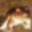

In [14]:
class RandomResizedCrop:
    """Random resized crop augmentation."""

    def __init__(self, size, scale=(0.2, 1.0)):
        self.size = size
        self.scale = scale

    def __call__(self, img):
        return transforms.RandomResizedCrop(self.size, scale=self.scale)(img)
    
RandomResizedCrop(32)(x)

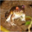

In [41]:
class ColorJitter: 
    def __init__(self,brightness=0.4,contrast=0.4,saturation=0.2,hue=0.2,prob=0.8):
        self.transform = transforms.ColorJitter(brightness,contrast,saturation,hue)
        self.prob = prob 

    def __call__(self,img):
        if torch.rand(1) < self.prob : 
            return self.transform(img)
        return img 

ColorJitter()(x)

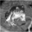

In [42]:
class GrayScale: 
    def __init__(self,prob=0.2): 
        self.prob = prob 

    def __call__(self,img): 
        if torch.rand(1) < self.prob : 
            return transforms.Grayscale(num_output_channels=3)(x)
        return img 
    
GrayScale()(x)

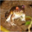

In [43]:
class Solarization: 
    def __init__(self,prob=0.1): 
        self.prob = prob

    def __call__(self,img): 
        if torch.rand(1) < self.prob:
            return transforms.functional.solarize(img,threshold=128)
        return img 
    
Solarization()(x)

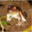

In [44]:
class HorizontalFlip: 
    def __init__(self,prob=0.5): 
        self.prob = prob

    def __call__(self,img):
        if torch.rand(1) < self.prob : 
            return transforms.functional.hflip(img)
        return img 

HorizontalFlip()(x)

# get_train_transforms | get_val_transforms

In [45]:
train_data.data.shape

(50000, 32, 32, 3)

In [46]:
print(torch.mean(torch.tensor(train_data.data / 255.),dim=(0,1,2)))
print(torch.std(torch.tensor(train_data.data / 255.),dim=(0,1,2)))

tensor([0.4914, 0.4822, 0.4465], dtype=torch.float64)
tensor([0.2470, 0.2435, 0.2616], dtype=torch.float64)


In [47]:
normalization = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

In [48]:
normalization(transforms.ToTensor()(x)).shape

torch.Size([3, 32, 32])

In [62]:
def get_train_transform(): 
    transform = transforms.Compose(
        [
            RandomResizedCrop(32,scale=(0.2,1.0)),
            ColorJitter(
                brightness=0.4,contrast=0.4,saturation=0.2,hue=0.1,prob =0.8
            ),
            GrayScale(prob=0.2),
            Solarization(prob=0.1),
            HorizontalFlip(prob=0.5),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

    return transform

get_train_transform()(x)

tensor([[[ 0.4787,  0.4787,  0.4787,  ...,  0.5562,  0.3042,  0.1879],
         [ 0.4399,  0.4593,  0.4593,  ...,  0.4787,  0.2654,  0.1685],
         [ 0.3624,  0.3624,  0.4205,  ...,  0.3430,  0.1879,  0.1297],
         ...,
         [ 0.6919,  0.7307,  0.9051,  ...,  2.0295,  2.0295,  1.9907],
         [ 0.6144,  0.7113,  0.8858,  ...,  2.0876,  2.1264,  2.1652],
         [ 0.5756,  0.6531,  0.9051,  ...,  2.1070,  2.2039,  2.2427]],

        [[-0.7269, -0.7269, -0.7269,  ..., -0.6876, -0.8252, -0.9039],
         [-0.7859, -0.7859, -0.7859,  ..., -0.7269, -0.8646, -0.9432],
         [-0.8842, -0.8646, -0.8252,  ..., -0.8646, -0.9629, -1.0022],
         ...,
         [-0.6089, -0.5302, -0.3139,  ...,  1.1218,  0.9054,  0.8268],
         [-0.9432, -0.7859, -0.4319,  ...,  1.4168,  1.2594,  1.2201],
         [-1.1006, -0.9432, -0.5696,  ...,  1.5544,  1.4561,  1.3971]],

        [[-0.7776, -0.7776, -0.7581,  ..., -0.7581, -0.8752, -0.9337],
         [-0.8167, -0.8167, -0.7776,  ..., -0

In [63]:
def get_val_transforms():
    """Get validation transforms."""
    return transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ]
    )

# Image Dataset 

In [ ]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self,dataset,transform,num_crops):
        self.dataset = dataset
        self.transform = transform
        self.num_crops =  num_crops
        

    def __len__(self):
        return len(self.dataset) 

    
    def __getitem__(self,idx): 
        image,label = self.dataset[idx]
        view = [self.transform(image) for _ in range(self.num_crops)]
        return view, label  # The author decided to make (2 images, 1 label) data sample 

In [71]:
train_ds = ImageDataset(
    dataset= train_data, 
    transform= get_train_transform(),
    num_crops= 2 
)

In [72]:
views,label = train_ds[0]
print(len(views))
print(views[0].shape)
print(views[1].shape)
print(label)

2
torch.Size([3, 32, 32])
torch.Size([3, 32, 32])
6


# Loader 

In [ ]:
from torch.utils.data import DataLoader

# num_workers is 2 in the script [for demostration purpose we'll use 0]
train_dl = DataLoader(train_ds, batch_size=32,shuffle=True,drop_last=True, num_workers=0)


In [92]:
for batch in train_dl: 
    views,labels = batch 
    print(len(views),label.shape)
    print(views[0].shape,views[1].shape,label.shape)
    break

2 torch.Size([32])
torch.Size([32, 3, 32, 32]) torch.Size([32, 3, 32, 32]) torch.Size([32])


# Result 

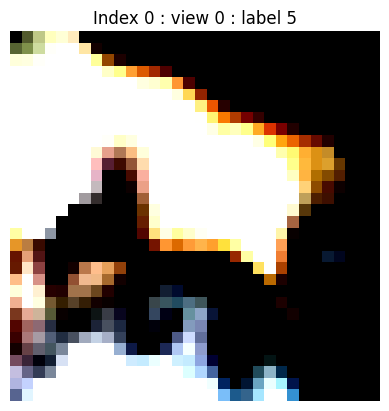

In [100]:
plt.imshow(views[0][0].permute(1,2,0).clamp(0,1))
plt.title(f'Index 0 : view 0 : label {label[0]}')
plt.axis("off")
plt.show()


# [C,H,W] --> [H,W,C]


In [ ]:

plt.title(f'Index 0 : view 0 : label {label[0]}')
plt.axis("off")
plt.show()